In [2]:
import pandas as pd
import numpy as np
from scipy.stats.mstats import winsorize
from datetime import datetime, timedelta
from warnings import filterwarnings
from tqdm import tqdm

# 假设 util 模块保持不变
from util import (load_and_preprocess_price, load_selection,
                  get_top_n_selection, compute_benchmark_returns,
                  compute_metrics, plot_results)

filterwarnings('ignore')

# ----------------------------
# 0. 用户配置参数
# ----------------------------
stock_num = 5               # 每个行业选5只
INITIAL_CASH = 1_000_000
START_DATE = '2020-01-01'
END_DATE   = '2025-06-30'
REBALANCE_FREQ = 5          # 每5个交易日调仓
TOP_N = 10                  # 最终组合选Top 10
HALFLIFE = 21               # 下行偏差的半衰期
RF_ANNUAL = 0.03 / 252      # 无风险利率(日化)

PRICE_FILE = 'eod_prices.parquet'
FUND_FILE = 'ETF_hold_510300.SH.parquet'
INDUSTRY_FILE = 'Stock_Industry_Year.parquet'

# ----------------------------
# 1. 核心计算函数 (来自代码1)
# ----------------------------
def ewma_alpha(halflives):
    return 1 - np.exp(-np.log(2) / halflives)

def calc_inv_log_dd_factor(series, halflives, rf):
    """
    计算因子: 1 / log(Downside_Deviation + 1e-10)
    """
    # 计算超额收益
    returns = np.log(series / series.shift(1)) - rf
    # 提取负收益
    r_neg = returns.where(returns <= 0, 0)
    r_neg_var = r_neg**2
    # EWMA 下行偏差
    alpha = ewma_alpha(halflives)
    dd = np.sqrt(r_neg_var.ewm(alpha=alpha).mean())
    # 取对数并求倒数
    log_dd = np.log(dd + 1e-10)
    inv_log_dd = 1.0 / log_dd
    return inv_log_dd

# ----------------------------
# 2. 数据预处理 & 股票池过滤
# ----------------------------
print("Loading base data & extracting CSI 300 universe...")
price_dt = pd.read_parquet(PRICE_FILE)
fund_df = pd.read_parquet(FUND_FILE)
industry_df = pd.read_parquet(INDUSTRY_FILE)

price_dt['trade_date'] = pd.to_datetime(price_dt['trade_date'])
fund_df['report_end_date'] = pd.to_datetime(fund_df['end_date'] if 'end_date' in fund_df.columns else fund_df['report_end_date'])

def get_position_valid_period(row):
    year = row['report_year']
    if row['report_type'] == '中报':
        return pd.Series([pd.to_datetime(f'{year}-01-01'), pd.to_datetime(f'{year}-06-30')], index=['pos_start_date', 'pos_end_date'])
    elif row['report_type'] == '年报':
        return pd.Series([pd.to_datetime(f'{year}-07-01'), pd.to_datetime(f'{year}-12-31')], index=['pos_start_date', 'pos_end_date'])
    else:
        return pd.Series([row['report_end_date'], row['report_end_date']], index=['pos_start_date', 'pos_end_date'])

fund_df[['pos_start_date', 'pos_end_date']] = fund_df.apply(get_position_valid_period, axis=1)
fund_holdings = fund_df[['stock_code', 'pos_start_date', 'pos_end_date']].drop_duplicates()

csi_300_stocks = fund_holdings['stock_code'].unique()
price_dt_subset = price_dt[price_dt['stock_code'].isin(csi_300_stocks)].sort_values(['stock_code', 'trade_date'])

# ----------------------------
# 3. 因子计算 (下行偏差倒数)
# ----------------------------
print(f"Calculating Downside Deviation Factor (Halflife={HALFLIFE})...")
df_factors_list = []

for stock, price_sub in tqdm(price_dt_subset.groupby('stock_code'), desc="Processing DD Factor"):
    temp_df = price_sub[['stock_code', 'trade_date', 'adjusted_close']].copy()
    # 计算因子
    temp_df['dd_factor'] = calc_inv_log_dd_factor(temp_df['adjusted_close'], HALFLIFE, RF_ANNUAL)
    df_factors_list.append(temp_df)

factor_dt = pd.concat(df_factors_list, ignore_index=True)

# 合并行业
factor_dt['year'] = factor_dt['trade_date'].dt.year
industry_df['year'] = industry_df['year'].astype(int)
factor_dt = factor_dt.merge(industry_df[['stock_code', 'year', 'industry_name']], on=['stock_code', 'year'], how='left')

# ----------------------------
# 4. 核心选股逻辑 (下行偏差中性化选股)
# ----------------------------
print("Executing daily stock selection...")

def select_stocks_by_date(date_group):
    trade_date = date_group.name
    daily_data = date_group.copy()
    
    valid_holdings = fund_holdings[
        (fund_holdings['pos_start_date'] <= trade_date) & 
        (fund_holdings['pos_end_date'] >= trade_date)
    ]['stock_code'].tolist()
    
    holding_stocks = daily_data[daily_data['stock_code'].isin(valid_holdings)]
    holding_stocks = holding_stocks.dropna(subset=['dd_factor', 'industry_name'])
    
    if len(holding_stocks) == 0: return pd.DataFrame()

    # 缩尾处理
    holding_stocks['factor_winsorized'] = winsorize(holding_stocks['dd_factor'].values, limits=(0.01, 0.01))
    
    # 行业内选因子值最大的（即下行风险最小的）
    selected = holding_stocks.groupby('industry_name', group_keys=False).apply(
        lambda x: x.sort_values('factor_winsorized', ascending=False).head(stock_num)
    )
    
    selected = selected.sort_values('factor_winsorized', ascending=False)
    selected['selection_rank'] = range(1, len(selected)+1)
    return selected

selected_stocks = factor_dt.groupby('trade_date', group_keys=False).apply(select_stocks_by_date)
final_selection_df = selected_stocks.reset_index(drop=True)

Loading base data & extracting CSI 300 universe...
Calculating Downside Deviation Factor (Halflife=21)...


Processing DD Factor: 100%|███████████████████████████████████████████████████████| 5693/5693 [00:13<00:00, 434.47it/s]


Executing daily stock selection...


In [6]:
final_selection_df.to_parquet('final_selection_downside_deviation20260327.parquet', index=False)

Starting backtest loop...

--- Performance Metrics (CSI 300 Low Downside-Deviation) ---
Annualized Return: 0.1732
Volatility: 0.1332
Sharpe Ratio: 1.3009
Max Drawdown: -0.1105


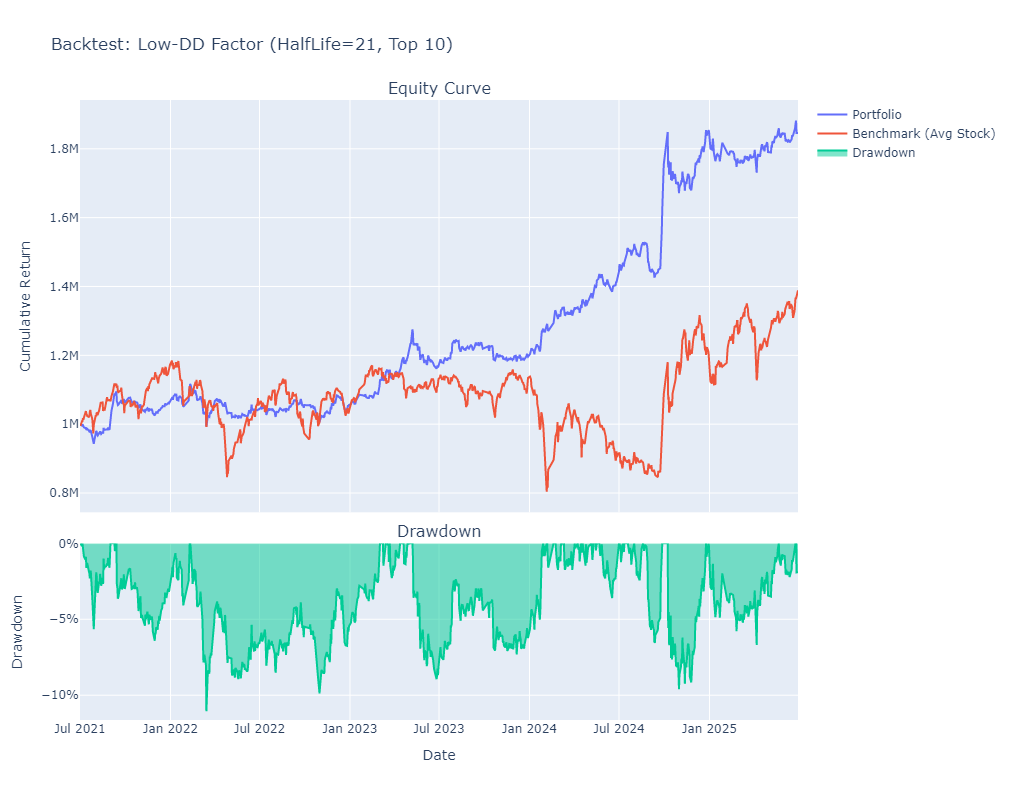

In [5]:
# ----------------------------
# 5. 回测循环
# ----------------------------

final_selection_df['trade_date'] = pd.to_datetime(final_selection_df['trade_date'].astype(str))
print("Starting backtest loop...")
# 1. 执行 pivot
price_pivot = price_dt.pivot(index='trade_date', columns='stock_code', values='adjusted_close').sort_index()
price_pivot.index = pd.to_datetime(price_pivot.index) 
price_pivot = price_pivot.loc[START_DATE:END_DATE]

selection_df = final_selection_df[(final_selection_df['trade_date'] >= START_DATE) & (final_selection_df['trade_date'] <= END_DATE)]
rebalance_dates = sorted(selection_df['trade_date'].unique())[::REBALANCE_FREQ]
timeline = [d for d in price_pivot.index if d >= rebalance_dates[0]]

cash, holdings, portfolio_values = INITIAL_CASH, {}, []
benchmark_daily, benchmark_cum = compute_benchmark_returns(price_pivot, START_DATE, END_DATE)

for date in timeline:
    today_prices = price_pivot.loc[date]
    if date in rebalance_dates:
        # 卖出
        for stock, shares in holdings.items():
            p = today_prices.get(stock, np.nan)
            if pd.notna(p): cash += shares * p
        holdings = {}
        # 选股 (基于 DD 因子排名的 Top N)
        selected = get_top_n_selection(selection_df, date, TOP_N)
        # 买入
        if selected:
            valid_stocks = [s for s in selected if pd.notna(today_prices.get(s, np.nan))]
            if valid_stocks:
                amt = cash / len(valid_stocks)
                for s in valid_stocks:
                    holdings[s] = amt / today_prices[s]
                cash = 0.0

    current_val = cash + sum(sh * today_prices.get(st, 0) for st, sh in holdings.items() if pd.notna(today_prices.get(st, 0)))
    portfolio_values.append(current_val)

# ----------------------------
# 6. 结果评价
# ----------------------------
portfolio_series = pd.Series(portfolio_values, index=timeline, name='Portfolio')
benchmark_funds = INITIAL_CASH * (benchmark_cum.reindex(timeline, method='ffill') / benchmark_cum.loc[timeline[0]])

portfolio_returns = portfolio_series.pct_change().dropna()
metrics = compute_metrics(portfolio_returns, rf=0, periods_per_year=252)

print("\n--- Performance Metrics (CSI 300 Low Downside-Deviation) ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

plot_results(portfolio_series, benchmark_funds, timeline, 
             title=f'Backtest: Low-DD Factor (HalfLife={HALFLIFE}, Top {TOP_N})')